In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv("../data/processed_news_nlp.csv")

print("Dataset shape:", df.shape)
print(df[["processed_text", "label"]].head())

Dataset shape: (38646, 10)
                                      processed_text  label
0  ben stein call th circuit court committed coup...      0
1  trump drop steve bannon national security coun...      1
2  puerto rico expects u lift jones act shipping ...      1
3  oops trump accidentally confirmed leaked israe...      0
4  donald trump head scotland reopen golf resort ...      1


In [4]:
X = df["processed_text"]
y = df["label"]

print("Number of articles:", len(X))
print("Number of labels:", len(y))

Number of articles: 38646
Number of labels: 38646


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))

Training articles: 30916
Testing articles: 7730


In [6]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [8]:
# Remove any missing text values
X_train = X_train.fillna("")
X_test = X_test.fillna("")

# Convert text to TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [10]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (30916, 50000)
Testing TF-IDF shape: (7730, 50000)


In [11]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated!")

Predictions generated!


In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

Accuracy: 0.9897800776196637

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3491
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3431   60]
 [  19 4220]]


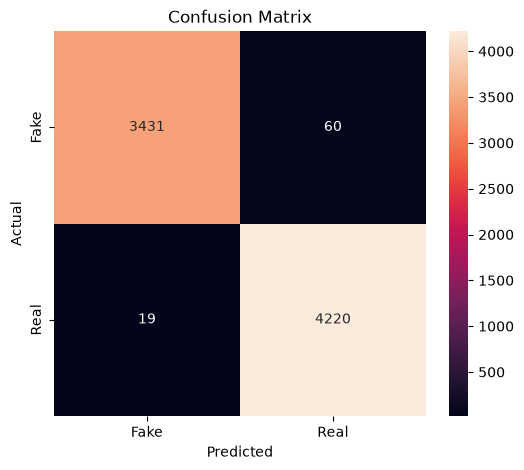

In [16]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()